In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
d_data = pd.read_csv(
    "data/d1322.csv",
    sep=r";",      # разделитель — пробелы/табы
    decimal=",",     # запятая как десятичный разделитель
    skiprows=[1],    # пропустить строку с единицами "мм мм"
    encoding="utf-8"
)
d = d_data["d_мк"].mean() # мм
d_d_stat = np.std(d_data["d_мк"], ddof=1) / np.sqrt(d_data["d_мк"].size) # мм
d_d_inst = 0.01 # мм
d_d = np.sqrt(d_d_stat ** 2 + d_d_inst ** 2)

R = d / 2 # мм
d_R = d_d / 2 # мм
print(R, d_R)

0.7816666666666667 0.005124707431905383


In [18]:
d_m = 5 # г
d_t = 0.01 # с
d_N = 0
h = 1730 # мм
d_h = 2 # мм

delta_l = 20 # мм
m = 204.1 # г

# Проблемы

## Задача: хотим мерить момент инерции грузов

Проблема: не знаем массу грузов!!! Я НЕ МЕРИЛ В БЛОКНОТ

Решение: Поиск по фотографии. На фотографии нашли значение в $204{,}1$ г.
На BlackSamorez была лаба, где второй груз имел такую массу, а первый - $202{,}5$ г.
В общем в моей работе используется значение для обоих в $204{,}1$ г, погрешность массы - 5 г.

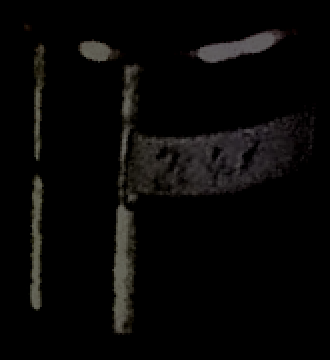

## Задача: хотим мерить момент инерции грузов, используя расстояние от оси до центра груза

Проблема: я мерил расстояние от оси до края груза

Решение:
$\Delta l = 20$ мм подобрано из соображений минимального отклонения (невязки) от прямой

попросил друга, разбирающегося в нейросетях помочь, он решил, и там получилось значение $19{,}67$ мм

С учетом нашей погрешности в 2 мм (1 мм от линейки 1 значение, 1 мм второе), нам достаточно 20.

Мне хотелось бы оформить это, но... времени не хватает :(

# Обработка данных

In [10]:
data = pd.read_csv(
    "data/data1322.csv",
    sep=r";",      # разделитель — пробелы/табы
    decimal=",",     # запятая как десятичный разделитель
    skiprows=[1],    # пропустить строку с единицами "мм мм"
    encoding="utf-8"
)

In [11]:
data["T"] = data["t"] / data["n"]
data["d_l"] = 2 # мм
data["d_T"] = d_t
data["T^2"] = data["T"] ** 2 # с^2
data["d_T^2"] = data["T^2"] * 2 * data["d_T"] / data["T"]

data["r"] = (data["l"] + delta_l) / 1000 # м
data["r^2"] = data["r"] ** 2
data["d_r^2"] = data["r^2"] * 2 * (data["d_l"] / 1000) / data["r"]
data["eps_alpha"] = data["d_T^2"] / data["T^2"] + data["d_r^2"] / data["r^2"]

# alpha = (2pi)^2 * 2m / f

data

,l,t,n,T,d_l,d_T,T^2,d_T^2,r,r^2,d_r^2,eps_alpha
0,20,70.27,39,1.801795,2,0.01,3.246465,0.036036,0.04,0.0016,0.00016,0.111100
1,30,33.32,17,1.960000,2,0.01,3.841600,0.039200,0.05,0.0025,0.00020,0.090204
2,40,42.91,20,2.145500,2,0.01,4.603170,0.042910,0.06,0.0036,0.00024,0.075989
3,60,41.02,16,2.563750,2,0.01,6.572814,0.051275,0.08,0.0064,0.00032,0.057801
4,80,45.19,15,3.012667,2,0.01,9.076160,0.060253,0.10,0.0100,0.00040,0.046639
5,110,55.88,15,3.725333,2,0.01,13.878108,0.074507,0.13,0.0169,0.00052,0.036138
6,10,51.32,31,1.655484,2,0.01,2.740627,0.033110,0.03,0.0009,0.00012,0.145414


In [12]:
def least_squares_line(x, y): # y = kx + b
    k = (np.mean(x*y) - np.mean(x) * np.mean(y)) / (np.mean(x*x) - (np.mean(x) ** 2))
    d_k = 1 / np.sqrt(len(x) - 1) * np.sqrt(((y*y).mean() - (y.mean() ** 2)) / ((x*x).mean() - (x.mean() ** 2)) - k ** 2)
    b = np.mean(y) - k * np.mean(x)
    d_b = d_k * np.sqrt(np.mean(x*x) - (np.mean(x) ** 2))
    return k, d_k, b, d_b

$T^2 = \frac{(2 \pi)^2}{f} I_0 + \frac{(2 \pi)^2}{f} 2m r^2$

$\alpha = \frac{(2\pi)^2}{f} 2m$

In [19]:
alpha, d_alpha_stat, hghg, ghghg = least_squares_line(data["r^2"], data["T^2"])
eps_alpha = data["eps_alpha"].mean()
d_alpha_inst = eps_alpha * alpha
d_alpha = np.sqrt(d_alpha_inst ** 2 + d_alpha_stat ** 2)
print(alpha, d_alpha)

f = (2 * np.pi) ** 2 * 2 * (m / 1000) / alpha # Н * м / рад
eps_f = d_m / m + d_alpha / alpha
d_f = eps_f * f
print(f, d_f)

696.1395432020576 56.02383153141542
0.023149223777712093 0.0024301052936424434


In [20]:
G = 2 * f * (h / 1000) / (np.pi * ((R / 1000) ** 4)) / 1000 / 1000 / 1000 # ГПа
eps_G = d_f / f + d_h / h + 4 * d_R / R
d_G = G * eps_G
print(G, d_G)

68.29301556015318 9.039007834602398


# Построение графика

In [37]:
mf_g, d_mf_g, mb_g, d_mb_g = least_squares_line(data["r^2"] * 10000, data["T^2"])
xline = np.linspace(0, 200, 10)
yline = xline * mf_g + mb_g

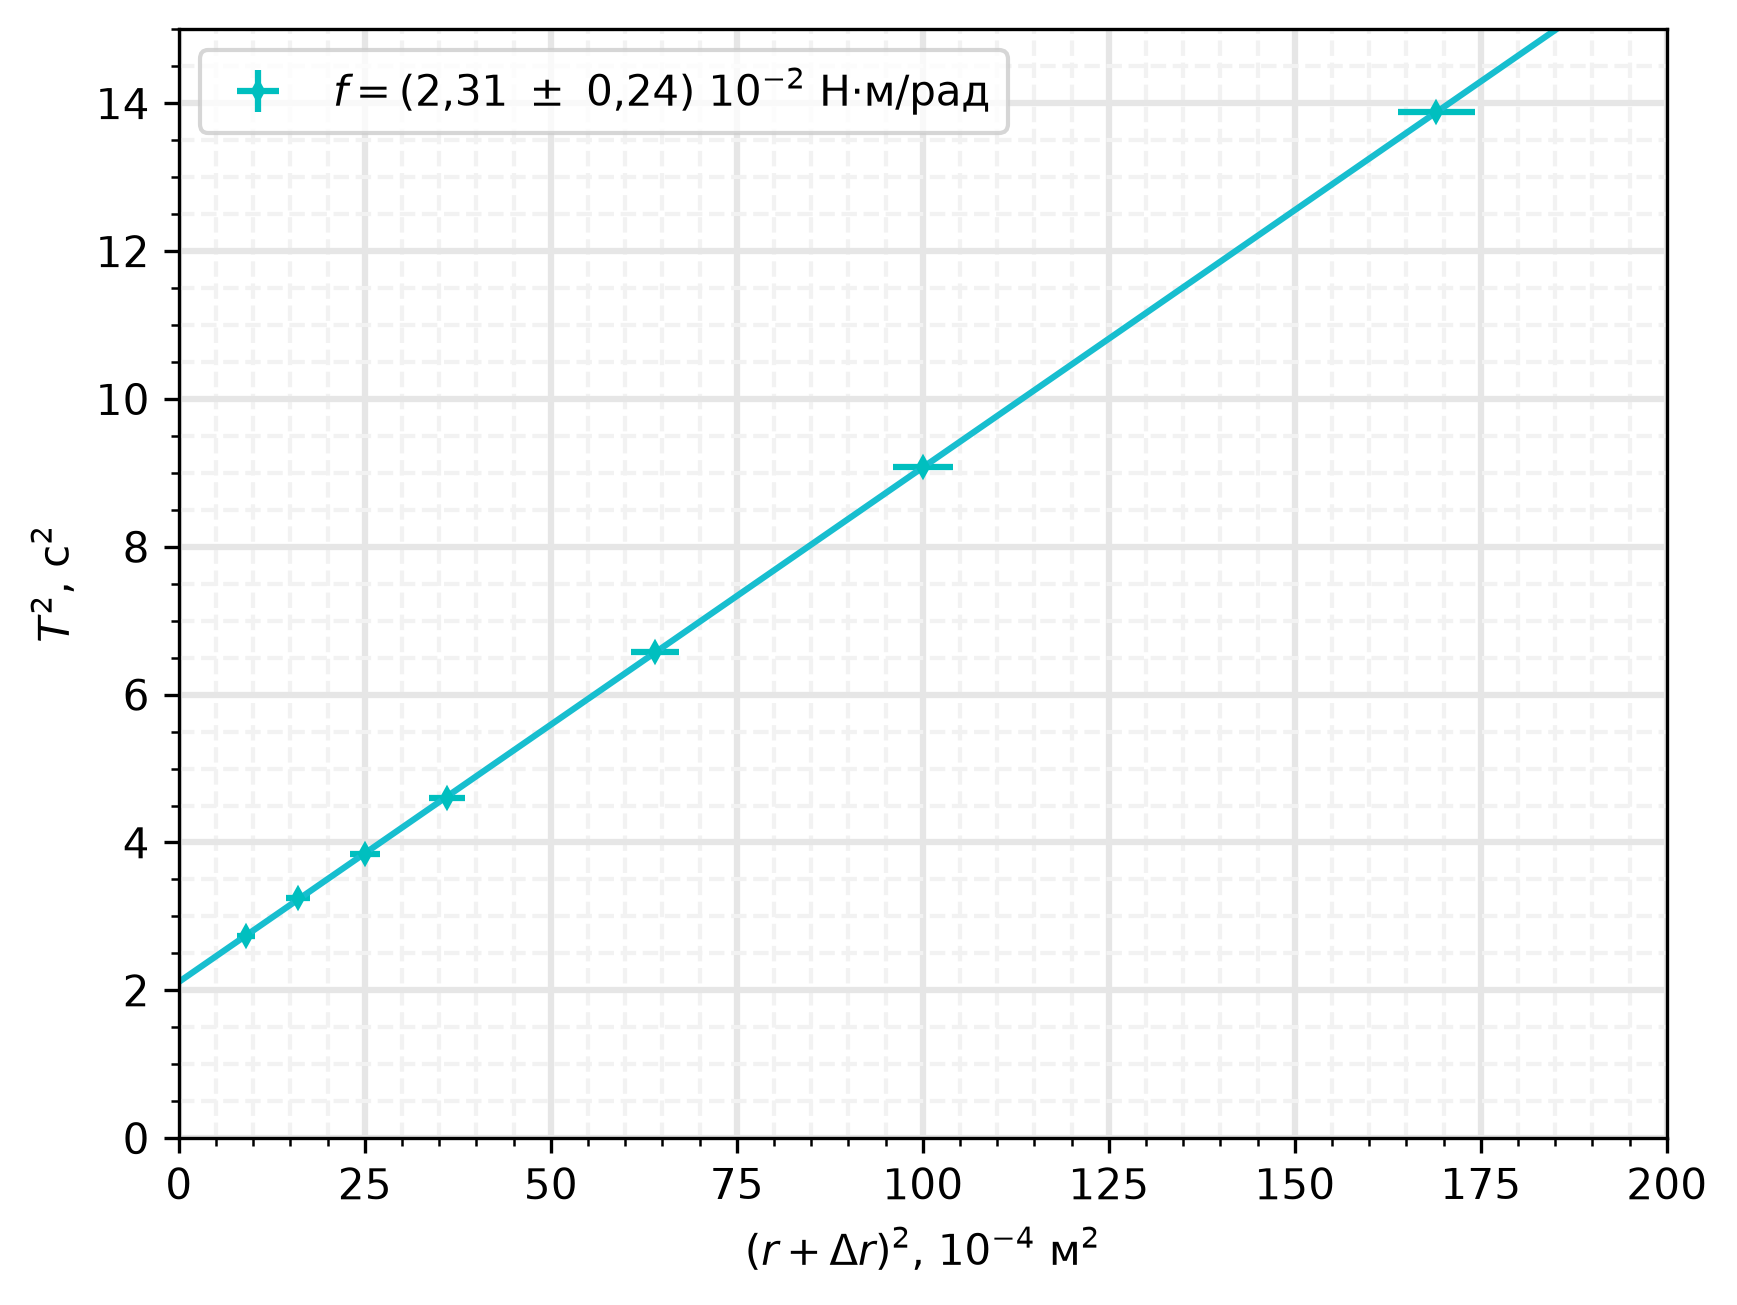

In [40]:
plt.figure(dpi=300)
plt.axis([0, 200, 0, 15])
plt.minorticks_on()
plt.xlabel("$(r+\\Delta r)^2$, $10^{-4}~{\\text{м}}^2$")
plt.ylabel("$T^2{,}~{\\text{с}^2}$")

plt.grid(visible=True, which='major', linestyle='-', linewidth=1.5, color='0.9') # Формат основных линиий сетки
plt.grid(visible=True, which='minor', linestyle='--', linewidth=1, color='0.95') # Формат побочных линий, цвет указывается как оттенок серого - 0.0 - чёрный, 1.0 - белый

plt.errorbar((data["r^2"] * 10000), data["T^2"], xerr=(data["d_r^2"] * 10000), yerr=data["d_T^2"], fmt="cd", markersize=3, label="$f=(2{,}31\\ \\pm\\ 0{,}24)$ $10^{-2}$ Н$\\cdot$м/рад")
plt.plot(xline, yline, color="tab:cyan")

plt.legend()
plt.savefig("images/graph1322.pdf", format="pdf")